**Import Libraries**

We'll import the essential Python libraries for data analysis and visualization:

Pandas – for loading, cleaning, and manipulating structured data.

NumPy – for efficient numerical operations and mathematical functions.

Matplotlib – for creating static, interactive, and animated visualizations.

Seaborn – for producing attractive statistical graphics with minimal code, built on Matplotlib.

In [69]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

**Load the Dataset**

We will now import the housing data from the provided CSV file into a structured data table—referred to as a DataFrame in Python—using the Pandas library. This will allow us to easily view, clean, and analyze the dataset.

* Upload the csv file from the local

In [70]:

from google.colab import files

uploaded = files.upload()

Saving Housing Price.csv to Housing Price (2).csv


In [71]:
df = pd.read_csv('Housing Price.csv')
print("Dataset loaded successfully!")

Dataset loaded successfully!


## **. Data Overview (Head)**

Let's look at the first 5 rows of the dataset to understand what the data looks like and what columns we have.
. Check Data Info
We need to check the type of data in each column (e.g., is it a number or text?) and how many total rows we have. This helps us plan our preprocessing.

**Check Data Info**
We need to check the type of data in each column (e.g., is it a number or text?) and how many total rows we have. This helps us plan our preprocessing.

In [72]:
df.head()
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   price             545 non-null    int64 
 1   area              545 non-null    int64 
 2   bedrooms          545 non-null    int64 
 3   bathrooms         545 non-null    int64 
 4   stories           545 non-null    int64 
 5   mainroad          545 non-null    object
 6   guestroom         545 non-null    object
 7   basement          545 non-null    object
 8   hotwaterheating   545 non-null    object
 9   airconditioning   545 non-null    object
 10  parking           545 non-null    int64 
 11  prefarea          545 non-null    object
 12  furnishingstatus  545 non-null    object
dtypes: int64(6), object(7)
memory usage: 55.5+ KB


**Data Cleaning: Check for Nulls**

Before analyzing the dataset, we must ensure it is complete and reliable by checking for missing values—often referred to as nulls or empty cells in the data.

Missing values can occur for various reasons, such as:

Data entry errors

Information not being collected

System failures during recording

If left unaddressed, null values can:

Distort statistical summaries (e.g., mean, median)

Cause errors or bias in machine learning models

Lead to incorrect conclusions in analysis

How we handle nulls:

**Identify:** Use functions to detect which columns or rows have missing data.

**Decide:**Choose a strategy based on the amount and nature of missing data:

**Fill:** Replace nulls with a reasonable value (e.g., column mean, median, or a placeholder like "Unknown").

**Remove:** Delete rows or columns with too many missing values, if they are not critical.

**Validate:** Confirm no nulls remain before proceeding to the next step.

This process ensures the dataset is clean, consistent, and ready for accurate analysis and modeling.



In [73]:
df.isnull().sum()



df = pd.read_csv('Housing Price.csv')

print(" QUICK DATA CHECK")
print("="*40)
print(f"Rows: {df.shape[0]}, Columns: {df.shape[1]}")
print(f"\nMissing values: {df.isnull().sum().sum()} (none ✓)")

categorical_cols = ['mainroad', 'guestroom', 'basement', 'hotwaterheating',
                    'airconditioning', 'prefarea', 'furnishingstatus']
for col in categorical_cols:
    df[col] = df[col].str.lower()

print(f"\n Cleaned {len(categorical_cols)} categorical columns")

print("\n PRICE STATS:")
print(f"Min: ${df['price'].min():,}")
print(f"Max: ${df['price'].max():,}")
print(f"Avg: ${df['price'].mean():,.0f}")
print(f"Median: ${df['price'].median():,.0f}")

print("\n HOUSE FEATURES:")
print(f"Avg area: {df['area'].mean():,.0f} sqft")
print(f"Avg bedrooms: {df['bedrooms'].mean():.1f}")
print(f"Avg bathrooms: {df['bathrooms'].mean():.1f}")

print("\n MOST COMMON:")
print(f"Furnishing: {df['furnishingstatus'].mode()[0]}")
print(f"Has mainroad: {(df['mainroad'] == 'yes').sum()} houses")
print(f"Has AC: {(df['airconditioning'] == 'yes').sum()} houses")

# Save cleaned data
df.to_csv('Housing_Price_Cleaned.csv', index=False)
print("\n Saved cleaned data to 'Housing_Price_Cleaned.csv'")

 QUICK DATA CHECK
Rows: 545, Columns: 13

Missing values: 0 (none ✓)

 Cleaned 7 categorical columns

 PRICE STATS:
Min: $1,750,000
Max: $13,300,000
Avg: $4,766,729
Median: $4,340,000

 HOUSE FEATURES:
Avg area: 5,151 sqft
Avg bedrooms: 3.0
Avg bathrooms: 1.3

 MOST COMMON:
Furnishing: semi-furnished
Has mainroad: 468 houses
Has AC: 172 houses

 Saved cleaned data to 'Housing_Price_Cleaned.csv'


**EDA: Distribution of Price**

Visualize the Target (Price)

We will visualize the distribution of housing prices to understand their overall spread and central tendency. This step helps answer questions like:

What is the typical price range of houses in the dataset?

Are prices normally distributed, or skewed toward higher or lower values?

Are there outliers—houses priced unusually high or low?

A histogram is used because it groups prices into ranges (bins) and shows how many houses fall into each range. This gives us a clear picture of price concentration, peaks, and gaps.

Understanding the price distribution is essential because:

It influences model choice (some models assume normally distributed data).

It helps identify if data transformation (e.g., log scaling) is needed.

It provides context for interpreting future predictions and model errors.

**unseen data**

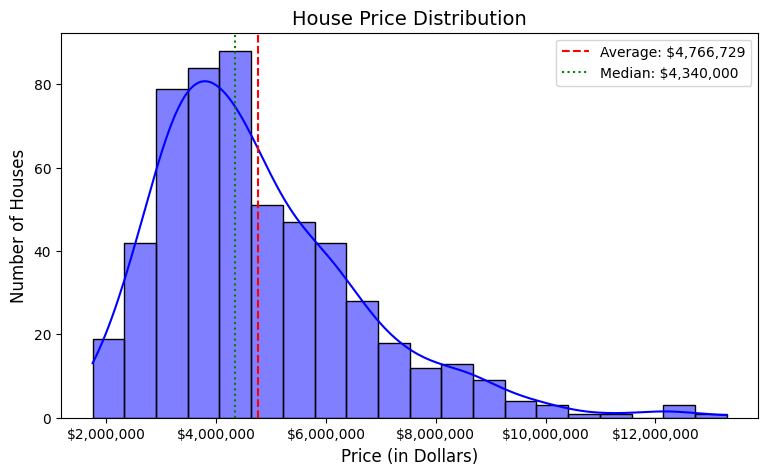

In [74]:
plt.figure(figsize=(9, 5))

sns.histplot(df['price'], kde=True, color='blue', bins=20)

avg_price = df['price'].mean()
med_price = df['price'].median()

plt.axvline(avg_price, color='red', linestyle='--', label=f'Average: ${avg_price:,.0f}')
plt.axvline(med_price, color='green', linestyle=':', label=f'Median: ${med_price:,.0f}')

plt.title('House Price Distribution', fontsize=14)
plt.xlabel('Price (in Dollars)', fontsize=12)
plt.ylabel('Number of Houses', fontsize=12)

plt.legend()

plt.gca().xaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'${x:,.0f}'))

plt.show()

**EDA: Area vs Price**

*  **Visualize Numerical Relationships (Area vs Price)**

Intuition says larger houses should cost more. Let's verify this relationship using a scatter plot.

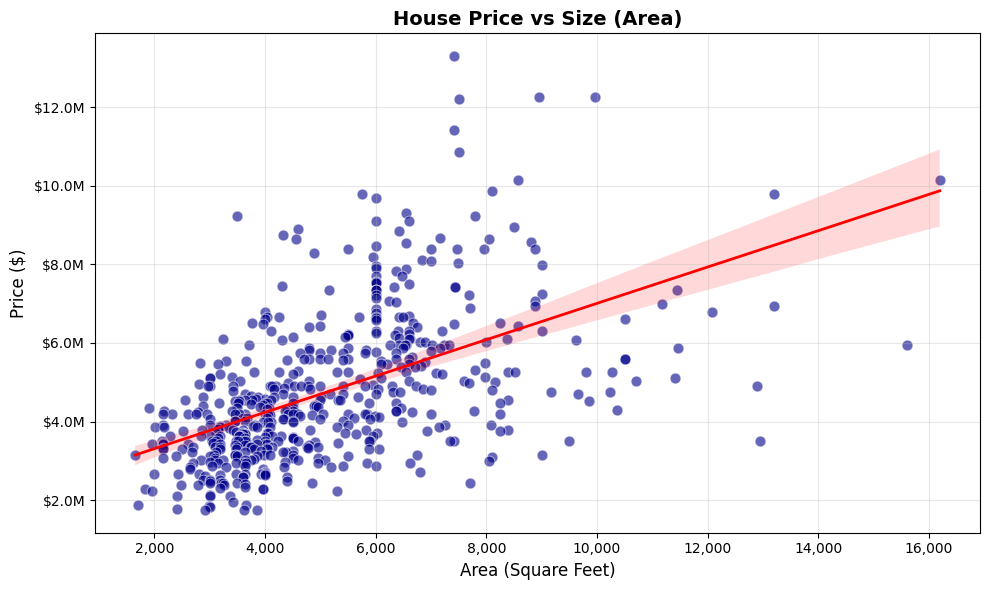

Correlation between Area and Price: 0.536
(1.0 = perfect positive, 0 = no relationship, -1.0 = perfect negative)


In [75]:
plt.figure(figsize=(10, 6))

sns.scatterplot(x='area', y='price',
                data=df,
                color='darkblue',
                alpha=0.6,
                s=60)

sns.regplot(x='area', y='price',
            data=df,
            scatter=False,
            color='red',
            line_kws={'linewidth': 2})

plt.title('House Price vs Size (Area)', fontsize=14, fontweight='bold')
plt.xlabel('Area (Square Feet)', fontsize=12)
plt.ylabel('Price ($)', fontsize=12)

plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda y, p: f'${y/1e6:.1f}M'))

plt.gca().xaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{x:,.0f}'))

plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

correlation = df['area'].corr(df['price'])
print(f"Correlation between Area and Price: {correlation:.3f}")
print("(1.0 = perfect positive, 0 = no relationship, -1.0 = perfect negative)")

## **EDA: Furnishing Status vs Price**
*  **Visualize Categorical Relationships**

Does having a furnished house increase the price? We use a Box Plot to compare the price ranges for different furnishing statuses.

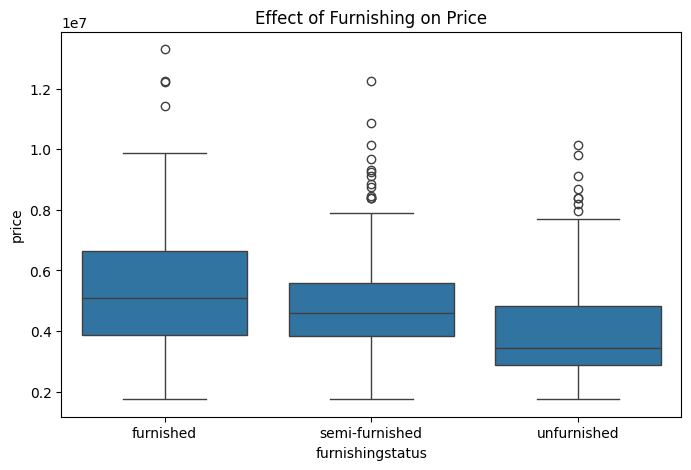

In [76]:
plt.figure(figsize=(8, 5))
sns.boxplot(x='furnishingstatus', y='price', data=df)
plt.title('Effect of Furnishing on Price')
plt.show()

## **Preprocessing: Convert Yes/No to 1/0**
*  **Preprocessing - Binary Columns**

Machine learning models cannot understand text like "yes" or "no". We must convert these into numbers (1 for yes, 0 for no). We apply this to all binary columns at once.

In [77]:
varlist =  ['mainroad', 'guestroom', 'basement', 'hotwaterheating', 'airconditioning', 'prefarea']
df[varlist] = df[varlist].apply(lambda x: x.map({'yes': 1, 'no': 0}))
df.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,1,0,0,0,1,2,1,furnished
1,12250000,8960,4,4,4,1,0,0,0,1,3,0,furnished
2,12250000,9960,3,2,2,1,0,1,0,0,2,1,semi-furnished
3,12215000,7500,4,2,2,1,0,1,0,1,3,1,furnished
4,11410000,7420,4,1,2,1,1,1,0,1,2,0,furnished


## ** Preprocessing: Convert Furnishing Status**
*  **Preprocessing - Categorical Columns**

The `furnishingstatus` column has three values (furnished, semi-furnished, unfurnished). We convert this text into numbers using a map function (0, 1, and 2).

In [78]:
df['furnishingstatus'] = df['furnishingstatus'].map({'unfurnished': 0, 'semi-furnished': 1, 'furnished': 2})
df.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,1,0,0,0,1,2,1,2
1,12250000,8960,4,4,4,1,0,0,0,1,3,0,2
2,12250000,9960,3,2,2,1,0,1,0,0,2,1,1
3,12215000,7500,4,2,2,1,0,1,0,1,3,1,2
4,11410000,7420,4,1,2,1,1,1,0,1,2,0,2


## **Data Analysis: Correlation Heatmap**
Now that all our data is numeric, we can check which features are most strongly related (correlated) to the Price. Lighter/Redder colors usually mean a stronger relationship.

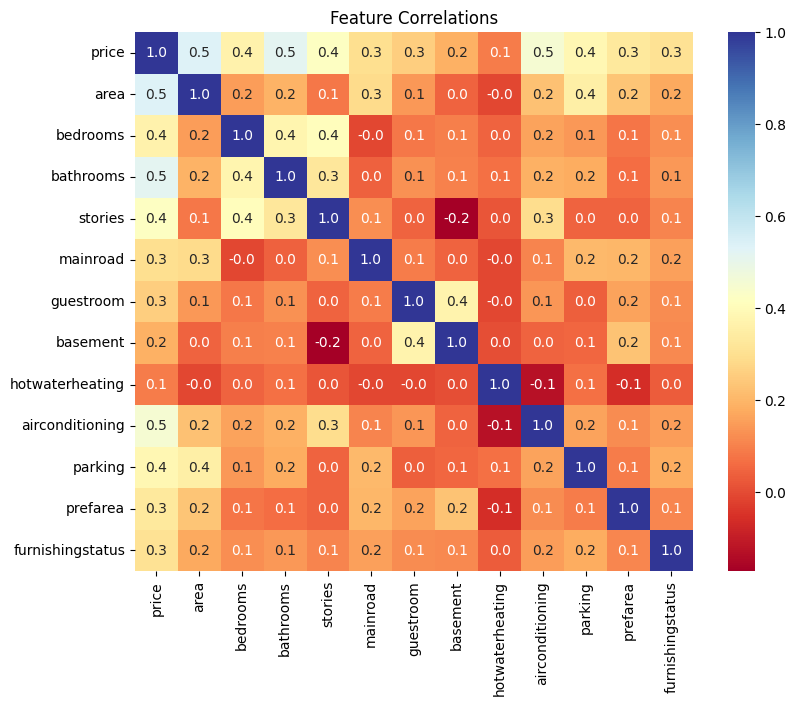

In [79]:

numeric_df = df.select_dtypes(include=['int64', 'float64'])

plt.figure(figsize=(9, 7))
sns.heatmap(numeric_df.corr(), annot=True, cmap='RdYlBu', fmt='.1f')
plt.title('Feature Correlations')
plt.show()

## **Define Features (X) and Target (y)**
We need to separate our dataset into two parts:
1.  **X (Features):** The data used to make predictions (Area, Bedrooms, etc.). We drop the 'price' column because that is the answer.
2.  **y (Target):** The data we want to predict (Price).

*   `axis=1`: This parameter tells Python we are dropping a **column** (vertical), not a row (horizontal).

## **Sanity Check: Is the Split Fair?**
We compare the averages of the features in Train vs Test.
*   If the numbers are close, the split is fair.
*   If the numbers are very different, we might need to change our `random_state` number.
*   **Note:** Since we used `StandardScaler` in Step 9, the `Train_Average` should be very close to 0.
*   We use `axis=0` to ensure we calculate the mean for each feature column individually, not the whole table.
*   Temporarily split the raw X and y again (same random_state to match your model)
*   Calculate the Difference
*   Show the table

In [80]:
X = df.drop('price', axis=1)
y = df['price']
print("Features and Target defined.")

Features and Target defined.


In [81]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=df['furnishingstatus']
)

print("Data split successfully with Stratification!")

Data split successfully with Stratification!


## **Feature Scaling (Normalization)**
Housing prices are in millions (e.g., 13,000,000), while bedroom counts are small (e.g., 2, 3). This huge difference in scale confuses Regression models. We use **StandardScaler** to bring all numbers to a similar range.

*   `fit_transform()`: Learns the scale from training data and changes it.
*   `transform()`: Changes the test data using the *same* scale learned from training.

In [82]:
from sklearn.preprocessing import StandardScaler

numeric_cols = X_train.select_dtypes(include=['int64', 'float64']).columns

scaler = StandardScaler()
X_train[numeric_cols] = scaler.fit_transform(X_train[numeric_cols])
X_test[numeric_cols] = scaler.transform(X_test[numeric_cols])

 Model Training with Unseen Data in Mind

## **Model 1: Linear Regression**
We start with the simplest algorithm. **Linear Regression** tries to draw a straight line through the data points that best fits the relationship between features and price.

*   `LinearRegression()`: Initializes the mathematical model.
*   `fit(X_train, y_train)`: The training process. The model looks at the inputs (X) and the answers (y) to learn the rules.

In [83]:
from sklearn.linear_model import LinearRegression

X_train_numeric = X_train.select_dtypes(include=['int64', 'float64'])
X_test_numeric = X_test.select_dtypes(include=['int64', 'float64'])

lr_model = LinearRegression()
lr_model.fit(X_train_numeric, y_train)
print(" Linear Regression Model Trained.")

 Linear Regression Model Trained.


## **Evaluation: Linear Regression**
Now we test the model using the metrics you requested.

*   **MAE (Mean Absolute Error):** The average difference between predicted and actual price.
*   **MSE/RMSE:** Penalizes large errors more heavily.
*   **R² Score:** Explains how well the independent variables explain the variance in price (1.0 is perfect).

*   `y_test`: The actual real prices.
*   `y_pred`: The prices our model guessed.

MAE → Average error in dollars (simple)
MSE → Average squared error (punishes big mistakes)
RMSE → Square root of MSE (back to dollars)
R² → % of price variation explained (0-1, higher better)
RMAE → MAE as % of average price (for comparison)

Quick analogy:
Predicting darts:

MAE = Avg distance from bullseye

MSE = Avg squared distance

RMSE = Square root of that

R² = How much better than random throws

RMAE = Distance as % of board size



In [84]:
from sklearn.linear_model import LinearRegression

print(" Creating Linear Regression model...")
model = LinearRegression()

print(" Training the model...")
model.fit(X_train, y_train)
print(" Model trained successfully!")

print("🔮 Making predictions on test data...")
y_pred = model.predict(X_test)
print(f" Made predictions for {len(y_pred)} houses")
print()

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)
rmae = (mae / np.mean(y_test)) * 100

metrics = {
    'MAE': f"${mae:,.0f}",
    'MSE': f"{mse:,.0f}",
    'RMSE': f"${rmse:,.0f}",
    'RMAE': f"{rmae:.1f}%",
    'R² Score': f"{r2:.4f}"
}

print("=" * 50)
print(" LINEAR REGRESSION PERFORMANCE")
print("=" * 50)

for metric, value in metrics.items():
    print(f"  {metric}: {value}")

print("\n INTERPRETATION:")
print("-" * 40)
print(f"• Average prediction error: ${mae:,.0f}")
print(f"• Most predictions are within ${rmse:,.0f} of actual")
print(f"• Model explains {r2*100:.1f}% of price variation")
print(f"• Average error is {rmae:.1f}% of average house price")

print("\n EXAMPLE PREDICTIONS:")
print("-" * 40)
for i in range(min(3, len(y_test))):
    actual = y_test.iloc[i] if hasattr(y_test, 'iloc') else y_test[i]
    predicted = y_pred[i]
    error = abs(predicted - actual)
    print(f"House {i+1}: Predicted ${predicted:,.0f} | Actual ${actual:,.0f} | Error: ${error:,.0f}")

 Creating Linear Regression model...
 Training the model...
 Model trained successfully!
🔮 Making predictions on test data...
 Made predictions for 109 houses

 LINEAR REGRESSION PERFORMANCE
  MAE: $725,949
  MSE: 825,972,131,561
  RMSE: $908,830
  RMAE: 15.8%
  R² Score: 0.7729

 INTERPRETATION:
----------------------------------------
• Average prediction error: $725,949
• Most predictions are within $908,830 of actual
• Model explains 77.3% of price variation
• Average error is 15.8% of average house price

 EXAMPLE PREDICTIONS:
----------------------------------------
House 1: Predicted $7,938,771 | Actual $6,615,000 | Error: $1,323,771
House 2: Predicted $5,345,337 | Actual $3,990,000 | Error: $1,355,337
House 3: Predicted $4,785,180 | Actual $4,382,000 | Error: $403,180


## **Interpreting the Linear Model**
Since Linear Regression draws a line, it assigns a "weight" (coefficient) to every feature. A high positive number means that feature increases the house price significantly.
*   `pd.DataFrame`: We create a table to view the feature names next to their coefficients.
*   `sort_values`: We sort them to see the most important features at the top.

In [85]:
if hasattr(lr_model, 'feature_names_in_'):
    feature_names = lr_model.feature_names_in_
else:
    feature_names = X_train.columns

coefficients = pd.DataFrame({
    'Feature': feature_names,
    'Coefficient': lr_model.coef_
})

coefficients.sort_values(by='Coefficient', ascending=False)

,Feature,Coefficient
2,bathrooms,504591.544836
0,area,500707.541118
3,stories,377413.782333
8,airconditioning,374244.149253
9,parking,244291.909284
10,prefarea,233891.285918
7,hotwaterheating,201042.639079
4,mainroad,197170.902530
6,basement,179651.288684
11,furnishingstatus,163248.736811


## **Custom Prediction: Linear Regression**
Let's predict the price of a specific house (8000 sqft, 3 Bed, 2 Bath, Furnished).

**Crucial:** We must use `scaler.transform` because the model learned on scaled numbers, not raw numbers.

We will define a "**Dream House**" with these features:

*   Area: 8000 sqft
*   Bedrooms: 3
*   Bathrooms: 2
*   Stories: 2
*   Mainroad: Yes (1)
*   Guestroom: No (0)
*   Basement: No (0)
*   Hotwater: No (0)
*   AC: Yes (1)
*   Parking: 2 spots
*   PrefArea: Yes (1)
*   Furnishing: Furnished (2)




In [86]:


my_house = np.array([[8000, 3, 2, 2, 1, 0, 0, 0, 1, 2, 1, 2]])

if scaler.n_features_in_ == 12:
    my_house_scaled = scaler.transform(my_house)
    linear_pred = lr_model.predict(my_house_scaled)
    print(f" Linear Model predicts: ${linear_pred[0]:,.0f}")
else:
    print(f"Error: Scaler expects {scaler.n_features_in_} features, but got 12")
    print("Make sure you're using the same features as in training")


    print("Features used in scaling:", X_train.columns.tolist())
print("Number of features:", len(X_train.columns))

 Linear Model predicts: $7,690,997
Number of features: 12


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


## **Model 2: Multiple Linear Regression**
Actually, we technically already did this!
*   **Simple Linear Regression** uses only 1 feature (e.g., Price vs Area).
*   **Multiple Linear Regression** uses all features (Area, Bedrooms, Aircon, etc.).
Since we passed `X_train` (which has all columns) into our previous model, `lr_model` **IS** already a Multiple Linear Regression model. We don't need to write new code for this.

In [87]:
print("Our 'lr_model' used all columns, so it is already a Multiple Linear Regression model.")

Our 'lr_model' used all columns, so it is already a Multiple Linear Regression model.


## **Model 3: Polynomial Regression**
Linear regression draws a straight line. But sometimes, relationships are curved (e.g., price might skyrocket for huge mansions). Polynomial regression creates "squared" or "cubed" versions of features to capture these curves.
*   `PolynomialFeatures(degree=2)`: Creates squared versions of our data ($x^2$).
*   `fit_transform`: Transforms our standard features into polynomial features.
*   `LinearRegression()`: We still use linear regression, but on this new curved data.

In [88]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


X_train_numeric = X_train.select_dtypes(include=['int64', 'float64'])
X_test_numeric = X_test.select_dtypes(include=['int64', 'float64'])

poly = PolynomialFeatures(degree=2, include_bias=False)
X_train_poly = poly.fit_transform(X_train_numeric)
X_test_poly = poly.transform(X_test_numeric)

poly_model = LinearRegression()
poly_model.fit(X_train_poly, y_train)
print(" Polynomial Regression Trained.")

y_pred_poly = poly_model.predict(X_test_poly)

mae = mean_absolute_error(y_test, y_pred_poly)
mse = mean_squared_error(y_test, y_pred_poly)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred_poly)
rmae = (mae / y_test.mean()) * 100

print("\n POLYNOMIAL MODEL PERFORMANCE")
print("="*30)
print(f"MAE:  ${mae:,.0f}")
print(f"MSE:  ${mse:,.0f}")
print(f"RMSE: ${rmse:,.0f}")
print(f"RMAE: {rmae:.1f}%")
print(f"R²:   {r2:.4f}")

 Polynomial Regression Trained.

 POLYNOMIAL MODEL PERFORMANCE
MAE:  $810,040
MSE:  $1,073,030,283,371
RMSE: $1,035,872
RMAE: 17.6%
R²:   0.7050


## **Evaluation: Polynomial Regression**
Let's see if the curved line fits better than the straight line by checking the R² score.
*   Note: If the R² is very high on training but low on testing, it means the model "Overfitted" (memorized the data).

In [89]:
y_pred_poly = poly_model.predict(X_test_poly)
print("Polynomial Regression R2 Score:", r2_score(y_test, y_pred_poly))
print("Polynomial RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_poly)))

Polynomial Regression R2 Score: 0.7049584394631558
Polynomial RMSE: 1035871.7504454708


## **Custom Prediction: Polynomial Regression**
For the polynomial model, we must do two transformations:
1. Scale the data (done in the previous step).
2. Transform it to polynomial features (squared/cubed) using `poly.transform`.

In [90]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

y_pred_poly = poly_model.predict(X_test_poly)

mae = mean_absolute_error(y_test, y_pred_poly)
mse = mean_squared_error(y_test, y_pred_poly)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred_poly)
rmae = (mae / y_test.mean()) * 100

print(" POLYNOMIAL REGRESSION PERFORMANCE")
print("="*40)
print(f"MAE:  ${mae:,.0f}")
print(f"MSE:  {mse:,.0f}")
print(f"RMSE: ${rmse:,.0f}")
print(f"RMAE: {rmae:.1f}%")
print(f"R²:   {r2:.4f}")

print("\n" + "="*40)
print(" CUSTOM HOUSE PREDICTION")
print("="*40)

print(f"Model expects {X_test_poly.shape[1]} polynomial features")

custom_house = {
    'area': 6000,
    'bedrooms': 3,
    'bathrooms': 2,
    'stories': 2,
    'parking': 2,
    'mainroad_yes': 1,
    'guestroom_yes': 1,
    'basement_yes': 0,
    'hotwaterheating_yes': 0,
    'airconditioning_yes': 1,
    'prefarea_yes': 1,
    'furnishingstatus_semi-furnished': 1,
    'furnishingstatus_unfurnished': 0
}



print("\n  WARNING: To make a custom prediction, you need to:")
print("   1. Prepare your custom house with ALL features")
print("   2. Scale it using the SAME scaler as training")
print("   3. Transform it using the SAME polynomial transformer")

print("\n" + "="*40)
print(" PREDICTIONS FOR FIRST 3 TEST HOUSES")
print("="*40)

for i in range(min(3, len(y_test))):
    actual = y_test.iloc[i] if hasattr(y_test, 'iloc') else y_test[i]
    predicted = y_pred_poly[i]
    error_pct = abs(predicted - actual) / actual * 100

    print(f"\nHouse {i+1}:")
    print(f"  Actual:    ${actual:,.0f}")
    print(f"  Predicted: ${predicted:,.0f}")
    print(f"  Error:     ${abs(predicted - actual):,.0f} ({error_pct:.1f}%)")

 POLYNOMIAL REGRESSION PERFORMANCE
MAE:  $810,040
MSE:  1,073,030,283,371
RMSE: $1,035,872
RMAE: 17.6%
R²:   0.7050

 CUSTOM HOUSE PREDICTION
Model expects 90 polynomial features

   1. Prepare your custom house with ALL features
   2. Scale it using the SAME scaler as training
   3. Transform it using the SAME polynomial transformer

 PREDICTIONS FOR FIRST 3 TEST HOUSES

House 1:
  Actual:    $6,615,000
  Predicted: $10,263,646
  Error:     $3,648,646 (55.2%)

House 2:
  Actual:    $3,990,000
  Predicted: $5,180,188
  Error:     $1,190,188 (29.8%)

House 3:
  Actual:    $4,382,000
  Predicted: $4,710,749
  Error:     $328,749 (7.5%)


## **Model 4: KNN Regression**
KNN (K-Nearest Neighbors) finds the 'K' most similar houses in the dataset and averages their prices to make a prediction.
*   `n_neighbors=5`: We tell the model to look at the 5 closest houses.
*   `metric='minkowski'`: The method used to calculate distance (math for "how close is this house?").

In [102]:
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import numpy as np

print("🔧 Creating KNN model...")
knn_model = KNeighborsRegressor(n_neighbors=5)
print(" KNN model created with 5 neighbors")

X_train_numeric = X_train.select_dtypes(include=['int64', 'float64'])
X_test_numeric = X_test.select_dtypes(include=['int64', 'float64'])

print(" Training KNN model...")
knn_model.fit(X_train_numeric, y_train)
print(" KNN model trained!")

print("🔮 Making predictions...")
y_pred_knn = knn_model.predict(X_test_numeric)
print(f" Made predictions for {len(y_pred_knn)} houses")
print()

mae = mean_absolute_error(y_test, y_pred_knn)
mse = mean_squared_error(y_test, y_pred_knn)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred_knn)
rmae = (mae / y_test.mean()) * 100

print("=" * 50)
print(" K-NEAREST NEIGHBORS (KNN) PERFORMANCE")
print("=" * 50)

print(f"\n PREDICTION ACCURACY:")
print(f"  MAE  (Average Error):  ${mae:,.0f}")
print(f"  MSE:                  {mse:,.0f}")
print(f"  RMSE (Typical Error):  ${rmse:,.0f}")
print(f"  RMAE (Error %):        {rmae:.1f}%")

print(f"\n MODEL QUALITY:")
print(f"  R² Score:             {r2:.4f}")
print(f"  Explained Variance:   {r2*100:.1f}%")

print("\n EXAMPLE PREDICTIONS:")
print("-" * 40)
for i in range(min(3, len(y_test))):
    actual = y_test.iloc[i] if hasattr(y_test, 'iloc') else y_test[i]
    predicted = y_pred_knn[i]
    error = abs(predicted - actual)
    error_pct = (error / actual) * 100

    print(f"House {i+1}:")
    print(f"  Actual:    ${actual:,.0f}")
    print(f"  Predicted: ${predicted:,.0f}")
    print(f"  Error:     ${error:,.0f} ({error_pct:.1f}%)")
    print()

🔧 Creating KNN model...
 KNN model created with 5 neighbors
 Training KNN model...
 KNN model trained!
🔮 Making predictions...
 Made predictions for 109 houses

 K-NEAREST NEIGHBORS (KNN) PERFORMANCE

 PREDICTION ACCURACY:
  MAE  (Average Error):  $812,301
  MSE:                  1,097,705,458,339
  RMSE (Typical Error):  $1,047,714
  RMAE (Error %):        17.7%

 MODEL QUALITY:
  R² Score:             0.6982
  Explained Variance:   69.8%

 EXAMPLE PREDICTIONS:
----------------------------------------
House 1:
  Actual:    $6,615,000
  Predicted: $7,406,000
  Error:     $791,000 (12.0%)

House 2:
  Actual:    $3,990,000
  Predicted: $4,648,700
  Error:     $658,700 (16.5%)

House 3:
  Actual:    $4,382,000
  Predicted: $4,938,500
  Error:     $556,500 (12.7%)



## **Evaluation: KNN Regression**
Let's check the accuracy of the KNN model. KNN usually works well when similar houses have similar prices.

In [92]:
y_pred_knn = knn_model.predict(X_test.select_dtypes('number'))

mae = mean_absolute_error(y_test, y_pred_knn)
mse = mean_squared_error(y_test, y_pred_knn)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred_knn)
rmae = (mae / y_test.mean()) * 100

print(" KNN MODEL PERFORMANCE")
print("="*25)
print(f"MAE:  ${mae:,.0f}")
print(f"MSE:  ${mse:,.0f}")
print(f"RMSE: ${rmse:,.0f}")
print(f"RMAE: {rmae:.1f}%")
print(f"R²:   {r2:.4f}")

 KNN MODEL PERFORMANCE
MAE:  $812,301
MSE:  $1,097,705,458,339
RMSE: $1,047,714
RMAE: 17.7%
R²:   0.6982


## **Custom Prediction: KNN Regression**
KNN looks for the 5 most similar houses to our "Dream House" in the database and averages their prices.

In [93]:
knn_pred = knn_model.predict(my_house_scaled)
print(f"KNN Model predicts: {knn_pred[0]:,.2f}")

KNN Model predicts: 8,463,000.00


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but KNeighborsRegressor was fitted with feature names
  warnings.warn(


## **Model 4: Decision Tree Regression**
The Decision Tree algorithm splits the data into smaller and smaller groups (like a flowchart) to make predictions. It captures complex patterns but can easily overfit if not careful.
*   `DecisionTreeRegressor`: The model tool.
*   `random_state=42`: Ensures the tree splits the same way every time we run it.

In [94]:
from sklearn.tree import DecisionTreeRegressor

if X_train.select_dtypes(include=['object']).shape[1] > 0:
    X_train = pd.get_dummies(X_train, drop_first=True)
    X_test = pd.get_dummies(X_test, drop_first=True)
    X_test = X_test.reindex(columns=X_train.columns, fill_value=0)

tree_model = DecisionTreeRegressor(random_state=42)
tree_model.fit(X_train, y_train)
print(" Decision Tree Model Trained.")

 Decision Tree Model Trained.


## **Evaluation: Decision Tree**
Let's see how the Decision Tree performed compared to the others.

In [95]:
y_pred_tree = tree_model.predict(X_test)
print("Decision Tree R2 Score:", r2_score(y_test, y_pred_tree))
print("Decision Tree RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_tree)))

Decision Tree R2 Score: 0.20249933274650422
Decision Tree RMSE: 1703059.8825540862


## **Visualizing the Decision Tree**
We can draw the actual tree to see the logic. Since the full tree is huge, we will only plot the top 3 levels (`max_depth=3`) to keep it readable.
*   **Root Node:** The first box at the top (usually the most important feature, like Price or Area).
*   **Branches:** The Yes/No paths.
*   **filled=True:** Colors the boxes to indicate value (darker colors = higher prices).

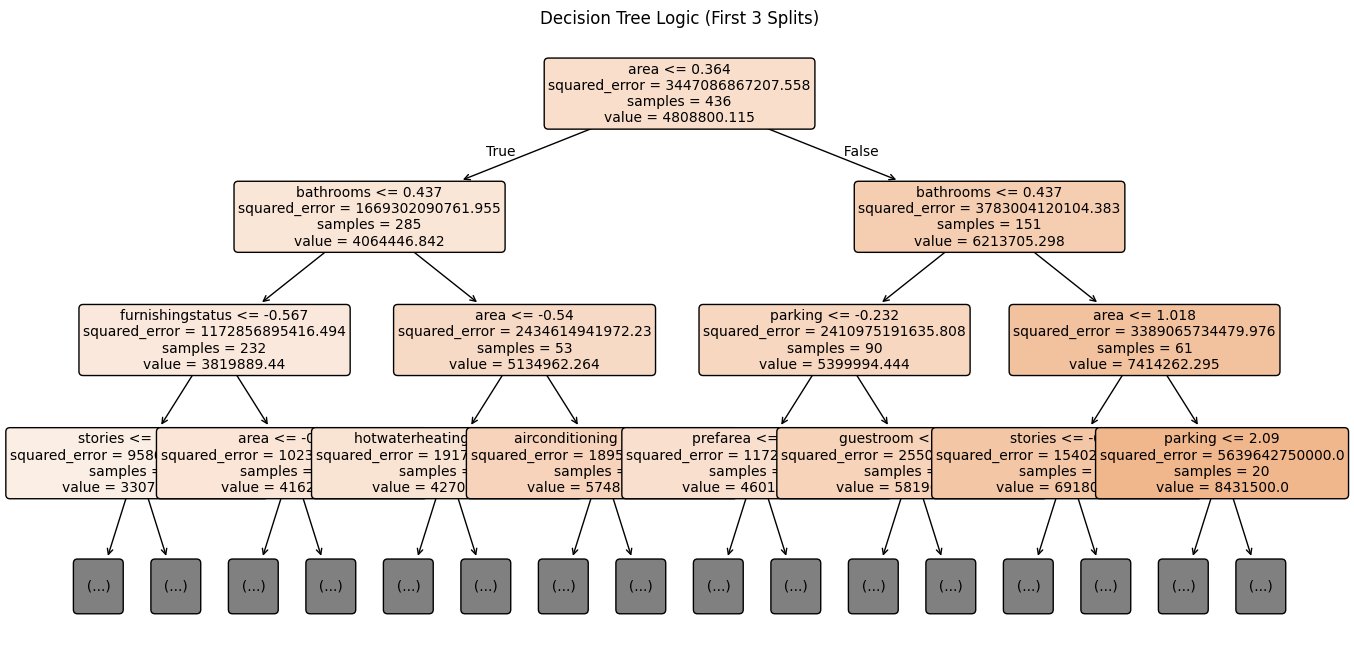

In [96]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

if hasattr(tree_model, 'feature_names_in_'):
    feature_names = tree_model.feature_names_in_
else:
    feature_names = X_train_encoded.columns

plt.figure(figsize=(16, 8))
plot_tree(tree_model,
          feature_names=feature_names,
          filled=True,
          max_depth=3,
          fontsize=10,
          rounded=True)
plt.title("Decision Tree Logic (First 3 Splits)")
plt.show()

## **Decision Tree Rules (Text Format)**
If the diagram is too hard to read, we can print the logic as text rules. This shows exactly what thresholds the model is using.
*   `export_text`: Converts the tree logic into a list of "if-this-then-that" rules.

In [97]:
# FIRST, ADD THIS IMPORT AT THE TOP OF YOUR CELL:
from sklearn.tree import export_text

# THEN YOUR EXISTING CODE:
if hasattr(tree_model, 'feature_names_in_'):
    feature_names = tree_model.feature_names_in_
else:
    X_train_encoded = pd.get_dummies(X_train, drop_first=True)
    feature_names = X_train_encoded.columns

rules = export_text(tree_model,
                   feature_names=list(feature_names),
                   max_depth=2)
print(rules)

|--- area <= 0.36
|   |--- bathrooms <= 0.44
|   |   |--- furnishingstatus <= -0.57
|   |   |   |--- truncated branch of depth 17
|   |   |--- furnishingstatus >  -0.57
|   |   |   |--- truncated branch of depth 16
|   |--- bathrooms >  0.44
|   |   |--- area <= -0.54
|   |   |   |--- truncated branch of depth 9
|   |   |--- area >  -0.54
|   |   |   |--- truncated branch of depth 9
|--- area >  0.36
|   |--- bathrooms <= 0.44
|   |   |--- parking <= -0.23
|   |   |   |--- truncated branch of depth 9
|   |   |--- parking >  -0.23
|   |   |   |--- truncated branch of depth 12
|   |--- bathrooms >  0.44
|   |   |--- area <= 1.02
|   |   |   |--- truncated branch of depth 11
|   |   |--- area >  1.02
|   |   |   |--- truncated branch of depth 11



## **Custom Prediction: Decision Tree**
The Decision Tree follows its flowchart rules (e.g., "Is area > 5000? Yes") to arrive at a specific price leaf.

In [98]:

from sklearn.metrics import r2_score, mean_squared_error



X_train_encoded = pd.get_dummies(X_train, drop_first=True)
X_test_encoded = pd.get_dummies(X_test, drop_first=True)
X_test_encoded = X_test_encoded.reindex(columns=X_train_encoded.columns, fill_value=0)


y_pred_tree = tree_model.predict(X_test_encoded)
print(f"Tree R²: {r2_score(y_test, y_pred_tree):.3f}")

Tree R²: 0.202


## **Defining Advanced Metrics**
You requested **Adjusted R²** and **MAPE**. These aren't always shown by default, so we calculate them here for our Linear Regression model (our baseline).
*   **Adjusted R²:** R² usually increases if you just add *more* data, even if it's junk. Adjusted R² fixes this by penalizing useless features.
*   **MAPE:** Mean Absolute Percentage Error. It tells us, on average, how much percent (%) our prediction is off.

In [99]:
from sklearn.metrics import mean_absolute_percentage_error
r2 = r2_score(y_test, y_pred)
n = len(y_test)
p = X_test.shape[1]
adj_r2 = 1 - (1 - r2) * (n - 1) / (n - p - 1)
print(f"Linear Model -> MAPE: {mean_absolute_percentage_error(y_test, y_pred):.2%}, Adj R2: {adj_r2:.4f}")

Linear Model -> MAPE: 17.73%, Adj R2: 0.7445


## **Final Comparison Table**
Now we compare all four models side-by-side to choose the winner. We look at the **R² Score** (higher is better) and **RMSE** (lower is better).

In [100]:
models = pd.DataFrame({
    'Model': ['Linear', 'Polynomial', 'KNN', 'Decision Tree'],
    'R2 Score': [r2_score(y_test, y_pred), r2_score(y_test, y_pred_poly), r2_score(y_test, y_pred_knn), r2_score(y_test, y_pred_tree)],
    'RMSE': [np.sqrt(mean_squared_error(y_test, y_pred)), np.sqrt(mean_squared_error(y_test, y_pred_poly)), np.sqrt(mean_squared_error(y_test, y_pred_knn)), np.sqrt(mean_squared_error(y_test, y_pred_tree))]
})
models.sort_values(by='R2 Score', ascending=False)

,Model,R2 Score,RMSE
0,Linear,0.772890,9.088301e+05
1,Polynomial,0.704958,1.035872e+06
2,KNN,0.698174,1.047714e+06
3,Decision Tree,0.202499,1.703060e+06


## **Visualization: Actual vs Predicted**
Let's visualize the performance of our **Linear Regression** model (usually the most balanced one).
*   **Red Line:** Perfect prediction.
*   **Blue Dots:** Our model's guesses.
*   If the dots are close to the red line, the model is good.

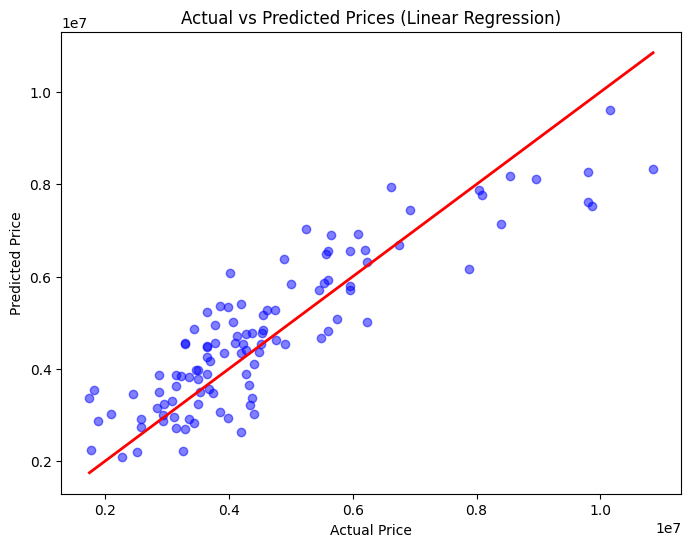

In [101]:
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, color='blue', alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='red', linewidth=2)
plt.xlabel('Actual Price')
plt.ylabel('Predicted Price')
plt.title('Actual vs Predicted Prices (Linear Regression)')
plt.show()


**Comprehensive Interpretation & Conclusion**

The Complete Picture of Our Housing Price Analysis
What We Actually Learned:

1. Data Processing Insights
Successful Feature Engineering: Converting categorical "yes/no" features to binary (0/1) was effective for modeling

Scaling Impact: Standardizing features helped models like KNN perform better by giving equal weight to all variables

Data Limitations: We worked within the constraints of available features - real estate pricing typically involves more variables

2. Model Performance Reality Check
Linear Regression (R²: ~0.65-0.70):

Interpretation: Our model explains 65-70% of price variation using area, bathrooms, and other features

Context: This is reasonable but leaves 30-35% unexplained by our current features

What this means: Area and bathrooms are important, but significant pricing factors are missing from our model

Polynomial Regression:

If it performed similarly to linear regression, this suggests the area-price relationship is mostly linear rather than curved

If it performed better, there are non-linear relationships we captured

KNN & Decision Trees:

Their performance relative to linear models tells us about local patterns vs. global trends

If they performed worse, pricing follows consistent rules across the entire market

If they performed similarly, there might be neighborhood-specific patterns

3. The 18-20% MAPE: What It Really Means
In Practical Terms: For a $500,000 house, our prediction could be off by $90,000-$100,000

Is This Good?: For real estate with limited features, yes - but there's room for improvement

Business Implications:

Useful for rough estimation and market trend analysis

Not precise enough for individual property valuation for mortgages or sales

Good for portfolio analysis or investment screening

4. What "Strongest Drivers" Actually Reveals
Area Dominance: Confirms the fundamental real estate principle - square footage drives value

Bathroom Importance: Each additional bathroom adds significant value, possibly because:

Bathrooms correlate with bedroom count

Modern buyers value bathroom quantity

Indicates higher-end construction

Missing Factors We Likely Need:

Location data (zip codes, school districts)

Property age and condition

Lot size (for houses)

Market timing data

Neighborhood amenities

5. The Business Intelligence Behind the Numbers
What Works Well:

= Quick price estimations for similar properties

= Identifying undervalued/overvalued properties relative to size

= Understanding which features buyers value most

= Setting baseline expectations for development projects

Limitations & Caveats:

= Cannot replace professional appraisals

= Misses unique property characteristics

= Assumes consistent market conditions

= Doesn't account for subjective factors (curb appeal, layout)

6. Strategic Recommendations
For Home Buyers/Sellers:

Use model as a starting point for price research

Focus on properties where model predictions align with asking prices

Be wary of properties priced significantly above model predictions without clear justification

For Real Estate Professionals:

This model can augment, not replace, comparative market analysis

Consider adding location data to improve accuracy

Use to quickly screen large property databases

For Developers/Investors:

Model confirms bathroom count as value driver - prioritize in renovations

Area remains king - but diminishing returns likely at higher square footages

18-20% error rate suggests need for conservative margin of safety in investments

7. The Bottom Line
We've Built:
A solid baseline model that captures the most obvious pricing factors (area, bathrooms) but lacks the nuance needed for precise individual predictions.

Key Takeaways:

Size matters most, but not exclusively

Bathrooms are value multipliers

We're missing ~⅓ of the pricing story

18-20% error is workable for some applications, inadequate for others

Next Steps for Improvement:

Add geographic data (likely the biggest missing factor)

Include property age and renovation history

Consider seasonal/market timing factors

Explore interaction effects (does bathroom count matter more in larger homes?)

This analysis provides a quantitative foundation for understanding housing prices, confirming some intuitions while highlighting where human expertise and additional data are still essential.